<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB
None
   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Advent

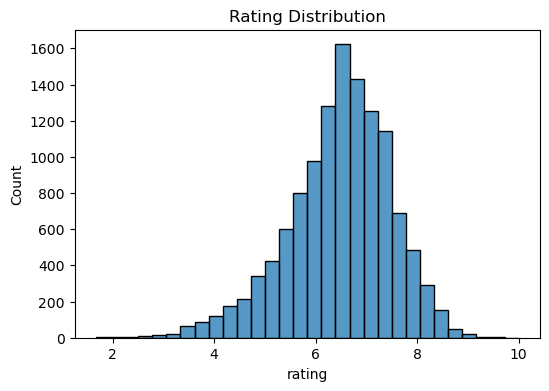

615                                    Naruto: Shippuuden
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
486                              Boruto: Naruto the Movie
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
Name: name, dtype: object

Threshold: 0.3
Number of Recommendations: 10
615                                    Naruto: Shippuuden
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
486                              Boruto: Naruto the Movie
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
1573    Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...
2458                 Naruto Shippuuden: Sunny Side Battle
2997    Naruto Soyokazeden Movie: Naruto to Mashin to ...
1796                                       Rekka no Honoo
784            Naruto: Shippuuden Movie 6 - Road to Ninja
Name: name, dtype: object

Threshold: 0.5
Number of Recomm

In [2]:
import pandas as pd
import numpy as np

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\anime.csv"
)

# ==========================================
# DATA OVERVIEW
# ==========================================

print(df.info())

print(df.head())

print(df.isnull().sum())

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

df["genre"] = df["genre"].fillna('')

df["rating"] = df["rating"].fillna(
    df["rating"].median()
)

df['episodes'] = df['episodes'].replace(
    'Unknown',
    np.nan
)

df['episodes'] = pd.to_numeric(
    df['episodes']
)

df['episodes'] = df['episodes'].fillna(
    df['episodes'].median()
)

print(df.describe())

# ==========================================
# VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.histplot(
    df['rating'],
    bins=30
)

plt.title("Rating Distribution")

plt.show()

# ==========================================
# TF-IDF FEATURE EXTRACTION
# ==========================================

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

tfidf = TfidfVectorizer(
    stop_words='english'
)

genre_matrix = tfidf.fit_transform(
    df['genre']
)

# ==========================================
# FEATURE SCALING
# ==========================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_features = scaler.fit_transform(
    df[['rating', 'episodes']]
)

# ==========================================
# COMBINE FEATURES
# ==========================================

from scipy.sparse import hstack

feature_matrix = hstack([
    genre_matrix,
    numeric_features
])

# ==========================================
# COSINE SIMILARITY
# ==========================================

from sklearn.metrics.pairwise import (
    cosine_similarity
)

cosine_sim = cosine_similarity(
    feature_matrix
)

# ==========================================
# RECOMMENDATION FUNCTION
# ==========================================

def recommend_anime(
    title,
    threshold=0.5,
    top_n=5
):

    if title not in df['name'].values:

        return "Anime not found!"

    idx = df[df['name'] == title].index[0]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    # Sort based on similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove itself
    similarity_scores = similarity_scores[1:]

    # Apply threshold
    similarity_scores = [
        i for i in similarity_scores
        if i[1] >= threshold
    ]

    # Top N recommendations
    top_anime = similarity_scores[:top_n]

    anime_indices = [
        i[0] for i in top_anime
    ]

    return df['name'].iloc[
        anime_indices
    ]

# ==========================================
# SAMPLE RECOMMENDATION
# ==========================================

print(
    recommend_anime(
        "Naruto",
        threshold=0.4,
        top_n=5
    )
)

# ==========================================
# THRESHOLD EXPERIMENTS
# ==========================================

thresholds = [0.3, 0.5, 0.7]

for t in thresholds:

    recommendations = recommend_anime(
        "Naruto",
        threshold=t,
        top_n=10
    )

    print(f"\nThreshold: {t}")

    print(
        "Number of Recommendations:",
        len(recommendations)
    )

    print(recommendations)

# ==========================================
# THRESHOLD ANALYSIS
# ==========================================

print("\n-----THRESHOLD ANALYSIS-----")

print(
    "Lower threshold values generated more recommendations."
)

print(
    "Higher threshold values produced fewer but more relevant recommendations."
)

print(
    "Threshold 0.3 generated a larger recommendation list."
)

print(
    "Threshold 0.7 produced only highly similar anime recommendations."
)


# Interview Questions

1. What is a Recommendation System?
A recommendation system suggests relevant items to users based on similarity, preferences, or user behavior.

2. What is Cosine Similarity?
Cosine similarity measures similarity between two vectors based on the cosine angle between them.

3. What is Collaborative Filtering?
Collaborative filtering recommends items based on interactions and preferences of similar users.

4. What is Content-Based Filtering?
Content-based filtering recommends items similar to previously liked items using item features.

5. Why is Feature Scaling important in Recommendation Systems?
Feature scaling ensures all features contribute equally to similarity calculations.